# 03c_Fault Scoring

## Objective
Build fault scoring and drift scoring per sensor-window using staged, interpretable rule-based and model-based frameworks.

Outputs:
1. Binary fault / no-fault per sensor per 24-hour window
2. Continuous drift score per sensor per 24-hour window

This notebook uses engineered features from `03b` and implements transparent, auditable scoring.

---

## Assumptions
- Output grain: sensor × 24-hour window
- Drift is persistent deviation from expected behaviour
- One-off spikes should not automatically become faults
- Sensors with no neighbours rely on self-history-only features
- Time-based train/validation split only (no random split)
- Scoring rules and thresholds are defined as named constants

---

## Inputs
- `/data/sensor_hour_features.csv` (from 03b)
- `/data/sensor_window_features.csv` (from 03b)
- `/data/feature_dictionary.csv` (from 03b)
- `/data/sensor_neighbour_metadata.csv` (from 03b)
- `/data/model_metric_list.csv` (from 03b)

---

## Outputs
1. `sensor_window_scores.csv` - Full scored sensor-window table
2. `top_fault_windows.csv` - Ranked suspicious windows
3. `fault_rule_parameters.json` - Documented thresholds and logic
4. `score_diagnostics.csv` - Diagnostic summary

## Setup and Configuration

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.figsize'] = (14, 7)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)

# Paths
root = Path('..')
data_dir = root / 'data'
outputs = data_dir

print('Setup complete.')

Setup complete.


## 1. Load Features and Validate Schema

In [2]:
# Define required files
required_files = {
    'hour_features': data_dir / 'sensor_hour_features.csv',
    'window_features': data_dir / 'sensor_window_features.csv',
    'feature_dict': data_dir / 'feature_dictionary.csv',
    'neighbour_meta': data_dir / 'sensor_neighbour_metadata.csv',
    'model_metrics': data_dir / 'model_metric_list.csv'
}

# Check for missing files
missing = [name for name, path in required_files.items() if not path.exists()]

if missing:
    print('\n' + '='*60)
    print('PREREQUISITE CHECKLIST - MISSING INPUTS')
    print('='*60)
    for name in missing:
        print(f'  [ ] {required_files[name]}')
    print('\nPlease run 03b_feature_engineering.ipynb first.')
    print('='*60)
    raise FileNotFoundError(f'Missing {len(missing)} required input files.')

print('All prerequisite files found.')

All prerequisite files found.


In [3]:
# Load data
hour_features = pd.read_csv(required_files['hour_features'])
window_features = pd.read_csv(required_files['window_features'])
feature_dict = pd.read_csv(required_files['feature_dict'])
neighbour_meta = pd.read_csv(required_files['neighbour_meta'])
model_metrics_df = pd.read_csv(required_files['model_metrics'])

# Extract metrics list
model_metrics = model_metrics_df['metric'].tolist()

# Convert timestamps
timestamp_col = 'timestamp_utc'
sensor_col = 'ateccid'

hour_features[timestamp_col] = pd.to_datetime(hour_features[timestamp_col])
window_features['window_start'] = pd.to_datetime(window_features['window_start'])
window_features['window_end'] = pd.to_datetime(window_features['window_end'])

print(f'Hour features shape: {hour_features.shape}')
print(f'Window features shape: {window_features.shape}')
print(f'Feature dictionary entries: {len(feature_dict)}')
print(f'Unique sensors: {neighbour_meta.shape[0]}')
print(f'Model metrics: {len(model_metrics)}')

Hour features shape: (25344, 573)
Window features shape: (1056, 105)
Feature dictionary entries: 571
Unique sensors: 33
Model metrics: 14


In [4]:
# Validate schema
required_cols_window = [sensor_col, 'window_start', 'window_end']
for col in required_cols_window:
    if col not in window_features.columns:
        raise ValueError(f'Missing required column in window_features: {col}')

required_cols_hour = [sensor_col, timestamp_col]
for col in required_cols_hour:
    if col not in hour_features.columns:
        raise ValueError(f'Missing required column in hour_features: {col}')

# Check for duplicates
dup_window = window_features.duplicated(subset=[sensor_col, 'window_start']).sum()
if dup_window > 0:
    raise ValueError(f'Found {dup_window} duplicate sensor-window combinations')

dup_hour = hour_features.duplicated(subset=[sensor_col, timestamp_col]).sum()
if dup_hour > 0:
    raise ValueError(f'Found {dup_hour} duplicate sensor-timestamp combinations')

# Confirm 24-hour window formation
window_features['window_duration'] = (window_features['window_end'] - window_features['window_start']).dt.total_seconds() / 3600
if not all(window_features['window_duration'] == 24):
    raise ValueError('Not all windows are exactly 24 hours')
window_features.drop('window_duration', axis=1, inplace=True)

print('✓ Schema validation passed')
print('✓ No duplicate sensor-window rows')
print('✓ All windows are 24 hours')

✓ Schema validation passed
✓ No duplicate sensor-window rows
✓ All windows are 24 hours


## 2. Build Rule-Based Baseline Scoring

In [5]:
# Define scoring thresholds and parameters
# These are auditable, named constants

RULE_PARAMS = {
    # Residual magnitude thresholds
    'residual_magnitude_threshold': 2.0,  # units above neighbour median
    'robust_z_threshold': 2.5,  # standard deviations (MAD-based)
    'relative_residual_threshold': 0.15,  # 15% of neighbour value
    
    # Persistence thresholds
    'min_persistence_hours': 6,  # minimum hours above threshold before alert
    'persistence_window_hours': 24,  # rolling window for persistence
    'persistence_ratio_threshold': 0.25,  # 25% of hours in window
    
    # Neighbour confidence
    'min_neighbour_coverage': 0.5,  # minimum neighbour data coverage
    'isolated_sensor_discount': 0.3,  # reduce score for isolated sensors
    
    # Rolling instability
    'instability_high_threshold': 0.5,  # high rolling std of residuals
    'instability_medium_threshold': 0.3,  # medium rolling std
    
    # Self-history for isolated sensors
    'self_deviation_threshold': 2.0,  # std from 24h median
    'self_slope_threshold': 0.1  # hourly trend magnitude
}

print('Rule-based scoring parameters defined:')
for key, val in RULE_PARAMS.items():
    print(f'  {key}: {val}')

Rule-based scoring parameters defined:
  residual_magnitude_threshold: 2.0
  robust_z_threshold: 2.5
  relative_residual_threshold: 0.15
  min_persistence_hours: 6
  persistence_window_hours: 24
  persistence_ratio_threshold: 0.25
  min_neighbour_coverage: 0.5
  isolated_sensor_discount: 0.3
  instability_high_threshold: 0.5
  instability_medium_threshold: 0.3
  self_deviation_threshold: 2.0
  self_slope_threshold: 0.1


In [6]:
# Function to compute rule-based score for a window
def compute_rule_score(window_row, hour_group, model_metrics):
    """
    Compute rule-based drift score from raw signal deviation.
    Score ranges [0, 1] where 1 is maximum anomaly.
    
    NOTE: Confidence is captured separately as a component and applied
    as a gating mechanism downstream, NOT multiplied here.
    This ensures anomaly magnitude and signal quality remain conceptually separate.
    """
    scores_components = {}
    
    # 1. Residual magnitude score
    residual_magnitudes = []
    robust_z_values = []
    
    for metric in model_metrics:
        abs_resid_col = f'{metric}_abs_residual'
        robust_z_col = f'{metric}_robust_z'
        
        if abs_resid_col in hour_group.columns:
            valid_resids = hour_group[abs_resid_col].dropna()
            if not valid_resids.empty:
                residual_magnitudes.append(valid_resids.max())
        
        if robust_z_col in hour_group.columns:
            valid_z = hour_group[robust_z_col].dropna().abs()
            if not valid_z.empty:
                robust_z_values.append(valid_z.max())
    
    if residual_magnitudes:
        max_resid = np.max(residual_magnitudes)
        score_residual = min(1.0, max_resid / RULE_PARAMS['residual_magnitude_threshold'])
    else:
        score_residual = 0.0
    
    scores_components['residual_magnitude_score'] = score_residual
    
    # 2. Robust z-score score
    if robust_z_values:
        max_z = np.max(robust_z_values)
        score_robust_z = min(1.0, max_z / RULE_PARAMS['robust_z_threshold'])
    else:
        score_robust_z = 0.0
    
    scores_components['robust_z_score'] = score_robust_z
    
    # 3. Persistence score (count of hours exceeding threshold)
    persist_hours = 0
    for metric in model_metrics:
        robust_z_col = f'{metric}_robust_z'
        if robust_z_col in hour_group.columns:
            exceed = (hour_group[robust_z_col].abs() > RULE_PARAMS['robust_z_threshold']).sum()
            persist_hours = max(persist_hours, exceed)
    
    score_persistence = min(1.0, persist_hours / RULE_PARAMS['persistence_window_hours'])
    scores_components['persistence_score'] = score_persistence
    
    # 4. Neighbour coverage confidence
    neighbour_coverage = window_row.get('mean_neighbour_coverage', 0.0)
    if neighbour_coverage >= RULE_PARAMS['min_neighbour_coverage']:
        confidence_neighbour = 1.0
    elif neighbour_coverage > 0:
        confidence_neighbour = neighbour_coverage / RULE_PARAMS['min_neighbour_coverage']
    else:
        confidence_neighbour = RULE_PARAMS['isolated_sensor_discount']
    
    scores_components['neighbour_confidence'] = confidence_neighbour
    
    # 5. Rolling instability score (for isolated sensors)
    instability_scores = []
    for metric in model_metrics:
        self_inst_col = f'{metric}_self_instability'
        if self_inst_col in hour_group.columns:
            valid_inst = hour_group[self_inst_col].dropna()
            if not valid_inst.empty:
                instability_scores.append(valid_inst.max())
    
    if instability_scores:
        max_inst = np.max(instability_scores)
        if max_inst > RULE_PARAMS['instability_high_threshold']:
            score_instability = 1.0
        elif max_inst > RULE_PARAMS['instability_medium_threshold']:
            score_instability = 0.5
        else:
            score_instability = 0.0
    else:
        score_instability = 0.0
    
    scores_components['instability_score'] = score_instability
    
    # Combine scores (weighted average)
    # NOTE: confidence_neighbour is NOT multiplied here; it gates the binary decision downstream
    final_rule_score = (
        0.35 * score_residual +
        0.35 * score_robust_z +
        0.20 * score_persistence +
        0.10 * score_instability
    )
    
    scores_components['final_rule_score'] = final_rule_score
    
    return scores_components

print('Rule-based scoring function defined.')


Rule-based scoring function defined.


In [7]:
# Apply rule-based scoring to all windows
rule_scores = []

for idx, window_row in window_features.iterrows():
    sensor = window_row[sensor_col]
    window_start = window_row['window_start']
    
    # Get hours in this window
    hour_group = hour_features[
        (hour_features[sensor_col] == sensor) &
        (hour_features[timestamp_col] >= window_start) &
        (hour_features[timestamp_col] < window_start + pd.Timedelta(hours=24))
    ]
    
    if len(hour_group) == 0:
        continue
    
    scores = compute_rule_score(window_row, hour_group, model_metrics)
    scores.update({
        sensor_col: sensor,
        'window_start': window_start,
        'hours_in_window': len(hour_group)
    })
    rule_scores.append(scores)

rule_scores_df = pd.DataFrame(rule_scores)
print(f'Computed rule-based scores for {len(rule_scores_df)} windows')
print(f'\nRule score statistics:')
print(rule_scores_df['final_rule_score'].describe())

Computed rule-based scores for 1056 windows

Rule score statistics:
count    1056.000000
mean        0.678299
std         0.385869
min         0.100000
25%         0.100000
50%         0.883333
75%         0.975000
max         1.000000
Name: final_rule_score, dtype: float64


## 3. Implement Persistence and Cooldown Logic

In [8]:
# Build hourly-level alert stream with persistence logic
def compute_hourly_alerts_with_persistence(hour_features, model_metrics, rule_params):
    """
    Generate hourly-level binary alerts using persistence thresholds.
    """
    hour_features = hour_features.sort_values([sensor_col, timestamp_col]).copy()
    
    # Mark raw alert: if robust_z exceeds threshold for any metric
    hour_features['raw_alert'] = 0
    
    for metric in model_metrics:
        robust_z_col = f'{metric}_robust_z'
        if robust_z_col in hour_features.columns:
            hour_features['raw_alert'] = np.where(
                (hour_features[robust_z_col].abs() > rule_params['robust_z_threshold']),
                1,
                hour_features['raw_alert']
            )
    
    # Rolling persistence: count alerts in window
    hour_features['persistence_hours'] = (
        hour_features.groupby(sensor_col)['raw_alert']
        .rolling(window=rule_params['persistence_window_hours'], min_periods=1)
        .sum()
        .reset_index(level=0, drop=True)
    )
    
    # Persistence alert: minimum persistence duration
    hour_features['persistence_alert'] = (
        hour_features['persistence_hours'] >= rule_params['min_persistence_hours']
    ).astype(int)
    
    return hour_features

# Apply persistence logic
hour_features = compute_hourly_alerts_with_persistence(hour_features, model_metrics, RULE_PARAMS)

# Summary
total_hours = len(hour_features)
raw_alerts = hour_features['raw_alert'].sum()
persist_alerts = hour_features['persistence_alert'].sum()

print(f'Total hourly records: {total_hours}')
print(f'Raw alerts (>robust_z threshold): {raw_alerts} ({100*raw_alerts/total_hours:.1f}%)')
print(f'Persistence alerts (min {RULE_PARAMS["min_persistence_hours"]}h): {persist_alerts} ({100*persist_alerts/total_hours:.1f}%)')

Total hourly records: 25344
Raw alerts (>robust_z threshold): 14280 (56.3%)
Persistence alerts (min 6h): 17172 (67.8%)


In [9]:
# Roll up persistence alerts to window level
window_persistence = hour_features.groupby([sensor_col, hour_features[timestamp_col].dt.floor('24h')]).agg({
    'raw_alert': 'sum',
    'persistence_alert': 'sum',
    'persistence_hours': 'max'
}).reset_index()

window_persistence.columns = [sensor_col, 'window_start', 'raw_alert_hours', 'persistence_alert_hours', 'max_persistence_hours']

# Add to rule scores
rule_scores_df = rule_scores_df.merge(
    window_persistence,
    on=[sensor_col, 'window_start'],
    how='left'
)

print('Persistence metrics added to rule scores.')
print(rule_scores_df[['raw_alert_hours', 'persistence_alert_hours', 'max_persistence_hours']].describe())

Persistence metrics added to rule scores.
       raw_alert_hours  persistence_alert_hours  max_persistence_hours
count      1056.000000              1056.000000            1056.000000
mean         13.522727                16.261364              14.505682
std          10.103420                10.992883              10.324037
min           0.000000                 0.000000               0.000000
25%           0.000000                 0.000000               0.000000
50%          17.000000                24.000000              19.000000
75%          24.000000                24.000000              24.000000
max          24.000000                24.000000              24.000000


## 4. Train Interpretable Expected-Behaviour Model

In [10]:
# Prepare data for model training using time-based split
# Sort by time and use earlier period for training

# Define features for model training
feature_cols = [
    'hour_of_day', 'day_of_week', 'weekend_flag', 'hour_sin', 'hour_cos',
    'neighbour_mode_encoded', 'neighbour_count',
]

# Add rolling features for each metric
for metric in model_metrics:
    self_mean_6h = f'{metric}_self_mean_6h'
    self_mean_24h = f'{metric}_self_mean_24h'
    self_std_24h = f'{metric}_self_std_24h'
    
    if self_mean_6h in hour_features.columns:
        feature_cols.append(self_mean_6h)
    if self_mean_24h in hour_features.columns:
        feature_cols.append(self_mean_24h)
    if self_std_24h in hour_features.columns:
        feature_cols.append(self_std_24h)

# Encode neighbour mode
hour_features['neighbour_mode_encoded'] = (hour_features['neighbour_mode'] == 'neighbour').astype(int)

# Target: absolute residual (measure of deviation)
target_cols = [f'{m}_abs_residual' for m in model_metrics]

# Compute aggregate target: max abs residual across metrics
hour_features['residual_severity'] = hour_features[target_cols].max(axis=1, skipna=True)

# Filter to available features
available_features = [col for col in feature_cols if col in hour_features.columns]

print(f'Available training features: {len(available_features)}')
print(available_features[:10])

Available training features: 49
['hour_of_day', 'day_of_week', 'weekend_flag', 'hour_sin', 'hour_cos', 'neighbour_mode_encoded', 'neighbour_count', 'tvoc_self_mean_6h', 'tvoc_self_mean_24h', 'tvoc_self_std_24h']


In [11]:
# Time-based train/test split: 70% training, 30% validation
hour_features_sorted = hour_features.sort_values(timestamp_col).reset_index(drop=True)

split_idx = int(0.7 * len(hour_features_sorted))
train_data = hour_features_sorted.iloc[:split_idx].copy()
val_data = hour_features_sorted.iloc[split_idx:].copy()

# Remove rows with missing values
train_clean = train_data[available_features + ['residual_severity']].dropna()
val_clean = val_data[available_features + ['residual_severity']].dropna()

X_train = train_clean[available_features]
y_train = train_clean['residual_severity']
X_val = val_clean[available_features]
y_val = val_clean['residual_severity']

print(f'Training set: {X_train.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')
print(f'\nTraining target statistics:')
print(y_train.describe())

Training set: 12341 samples
Validation set: 5247 samples

Training target statistics:
count    1.234100e+04
mean     1.185720e+05
std      2.143774e+05
min      7.845666e+00
25%      2.528481e+04
50%      5.942659e+04
75%      1.274040e+05
max      1.892493e+06
Name: residual_severity, dtype: float64


In [12]:
# Train multiple interpretable models and select best
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

models = {
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=1000),
    'RandomForest': RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=50, max_depth=4, random_state=42)
}

model_results = {}
for name, model in models.items():
    # Train
    if name in ['Ridge', 'ElasticNet']:
        model.fit(X_train_scaled, y_train)
        y_pred_train = model.predict(X_train_scaled)
        y_pred_val = model.predict(X_val_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
    
    # Evaluate
    mse_train = mean_squared_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)
    mse_val = mean_squared_error(y_val, y_pred_val)
    r2_val = r2_score(y_val, y_pred_val)
    
    model_results[name] = {
        'model': model,
        'mse_train': mse_train,
        'r2_train': r2_train,
        'mse_val': mse_val,
        'r2_val': r2_val
    }
    
    print(f'{name}:')
    print(f'  Train: MSE={mse_train:.4f}, R²={r2_train:.4f}')
    print(f'  Val:   MSE={mse_val:.4f}, R²={r2_val:.4f}')

# Select best model by validation R²
best_model_name = max(model_results, key=lambda x: model_results[x]['r2_val'])
best_model = model_results[best_model_name]['model']

print(f'\n✓ Best model: {best_model_name} (Val R²={model_results[best_model_name]["r2_val"]:.4f})')

Ridge:
  Train: MSE=6152117400.0123, R²=0.8661
  Val:   MSE=8488932564.9001, R²=0.8355
ElasticNet:
  Train: MSE=6822712770.7080, R²=0.8515
  Val:   MSE=8449062077.5164, R²=0.8363
RandomForest:
  Train: MSE=664166714.1677, R²=0.9855
  Val:   MSE=2499256431.9304, R²=0.9516
GradientBoosting:
  Train: MSE=671363309.6803, R²=0.9854
  Val:   MSE=2000403149.7048, R²=0.9612

✓ Best model: GradientBoosting (Val R²=0.9612)


## 5. Create Final Drift Score

In [13]:
# Generate model-based residual predictions for all windows
# For each window, predict expected residual severity

model_scores = []

for idx, window_row in window_features.iterrows():
    sensor = window_row[sensor_col]
    window_start = window_row['window_start']
    
    # Get hours in this window
    hour_group = hour_features[
        (hour_features[sensor_col] == sensor) &
        (hour_features[timestamp_col] >= window_start) &
        (hour_features[timestamp_col] < window_start + pd.Timedelta(hours=24))
    ]
    
    if len(hour_group) == 0:
        continue
    
    # Prepare features
    X_window = hour_group[available_features].copy()
    
    # Make prediction
    if best_model_name in ['Ridge', 'ElasticNet']:
        X_window_scaled = scaler.transform(X_window.fillna(0))
        y_pred = best_model.predict(X_window_scaled)
    else:
        y_pred = best_model.predict(X_window.fillna(0))
    
    # Get actual residuals
    y_actual = hour_group['residual_severity'].values
    
    # Compute model-based score
    residual_error = np.abs(y_actual - y_pred).max() if len(y_pred) > 0 else 0
    model_residual_score = min(1.0, residual_error / RULE_PARAMS['residual_magnitude_threshold'])
    
    model_scores.append({
        sensor_col: sensor,
        'window_start': window_start,
        'model_name': best_model_name,
        'model_residual_error': residual_error,
        'model_residual_score': model_residual_score,
        'hours_scored': len(y_pred)
    })

model_scores_df = pd.DataFrame(model_scores)
print(f'Model-based scores computed for {len(model_scores_df)} windows')
print(f'Model: {best_model_name}')

Model-based scores computed for 1056 windows
Model: GradientBoosting


In [14]:
# FINAL DRIFT SCORE: Combine rule-based and model-based scores

# Merge rule and model scores
combined_scores = rule_scores_df.merge(
    model_scores_df[[sensor_col, 'window_start', 'model_residual_score', 'model_name']],
    on=[sensor_col, 'window_start'],
    how='left'
)

# Final drift score: weighted combination
combined_scores['drift_score'] = (
    0.6 * combined_scores['final_rule_score'] +   # Rule-based: 60%
    0.4 * combined_scores['model_residual_score'].fillna(0)  # Model-based: 40%
)

# Clamp to [0, 1]
combined_scores['drift_score'] = combined_scores['drift_score'].clip(0, 1)

print('Final drift score computed.')
print(f'\nDrift score statistics:')
print(combined_scores['drift_score'].describe())
print(f'\nComponent correlation:')
print(combined_scores[['final_rule_score', 'model_residual_score', 'drift_score']].corr())

Final drift score computed.

Drift score statistics:
count    1056.000000
mean        0.806979
std         0.231521
min         0.460000
25%         0.460000
50%         0.930000
75%         0.985000
max         1.000000
Name: drift_score, dtype: float64

Component correlation:
                      final_rule_score  model_residual_score  drift_score
final_rule_score                   1.0                   NaN          1.0
model_residual_score               NaN                   NaN          NaN
drift_score                        1.0                   NaN          1.0


In [16]:
# Validate score completeness before binary classification
print('Checking combined_scores completeness before binary fault flag generation...')

cols_to_check = [
    'final_rule_score',
    'model_residual_score',
    'drift_score',
    'hours_in_window',
    'neighbour_confidence'
]

print('\nColumn completeness:')
print(combined_scores[cols_to_check].isna().sum())

missing_model = combined_scores['model_residual_score'].isna().sum()
print(f'\nMissing model_residual_score rows: {missing_model} / {len(combined_scores)}')

if missing_model > 0:
    print('\nSample rows with missing model_residual_score:')
    print(
        combined_scores.loc[
            combined_scores['model_residual_score'].isna(),
            ['final_rule_score', 'drift_score', 'hours_in_window', 'neighbour_confidence']
        ].head(10).to_string(index=False)
    )

print('\nHours in window summary:')
print(combined_scores['hours_in_window'].describe())

print('\nNeighbour confidence summary:')
print(combined_scores['neighbour_confidence'].describe())


Checking combined_scores completeness before binary fault flag generation...

Column completeness:
final_rule_score        0
model_residual_score    0
drift_score             0
hours_in_window         0
neighbour_confidence    0
dtype: int64

Missing model_residual_score rows: 0 / 1056

Hours in window summary:
count    1056.0
mean       24.0
std         0.0
min        24.0
25%        24.0
50%        24.0
75%        24.0
max        24.0
Name: hours_in_window, dtype: float64

Neighbour confidence summary:
count    1056.000000
mean        0.786900
std         0.322006
min         0.300000
25%         0.300000
50%         1.000000
75%         1.000000
max         1.000000
Name: neighbour_confidence, dtype: float64


## 6. Create Final Binary Fault Flag

In [17]:
# Define thresholds for binary classification
FAULT_THRESHOLD = 0.60  # drift score threshold
CONFIDENCE_THRESHOLD = 0.50  # minimum confidence required

# Compute confidence scores
combined_scores['scoring_confidence'] = np.where(
    combined_scores['hours_in_window'] >= 18,
    1.0,
    combined_scores['hours_in_window'] / 18.0
)

# Neighbour evidence confidence
combined_scores['neighbour_evidence_confidence'] = combined_scores['neighbour_confidence']

# Fallback confidence (for isolated sensors)
combined_scores['fallback_confidence'] = np.where(
    combined_scores['neighbour_confidence'] >= 0.9,
    1.0,
    RULE_PARAMS['isolated_sensor_discount']
)

# Overall confidence
combined_scores['overall_confidence'] = (
    combined_scores['scoring_confidence'] * 
    combined_scores['neighbour_evidence_confidence'] *
    combined_scores['fallback_confidence']
)

# Binary fault flag: drift score above threshold AND sufficient confidence
combined_scores['binary_fault_flag'] = (
    (combined_scores['drift_score'] >= FAULT_THRESHOLD) &
    (combined_scores['overall_confidence'] >= CONFIDENCE_THRESHOLD)
).astype(int)

print(f'Binary fault flag thresholds:')
print(f'  Drift score threshold: {FAULT_THRESHOLD}')
print(f'  Confidence threshold: {CONFIDENCE_THRESHOLD}')
print(f'\nFault flag distribution:')
print(combined_scores['binary_fault_flag'].value_counts())
print(f'\nFault rate: {combined_scores["binary_fault_flag"].mean()*100:.1f}%')

Binary fault flag thresholds:
  Drift score threshold: 0.6
  Confidence threshold: 0.5

Fault flag distribution:
binary_fault_flag
1    733
0    323
Name: count, dtype: int64

Fault rate: 69.4%


## 7. Validation and Diagnostics

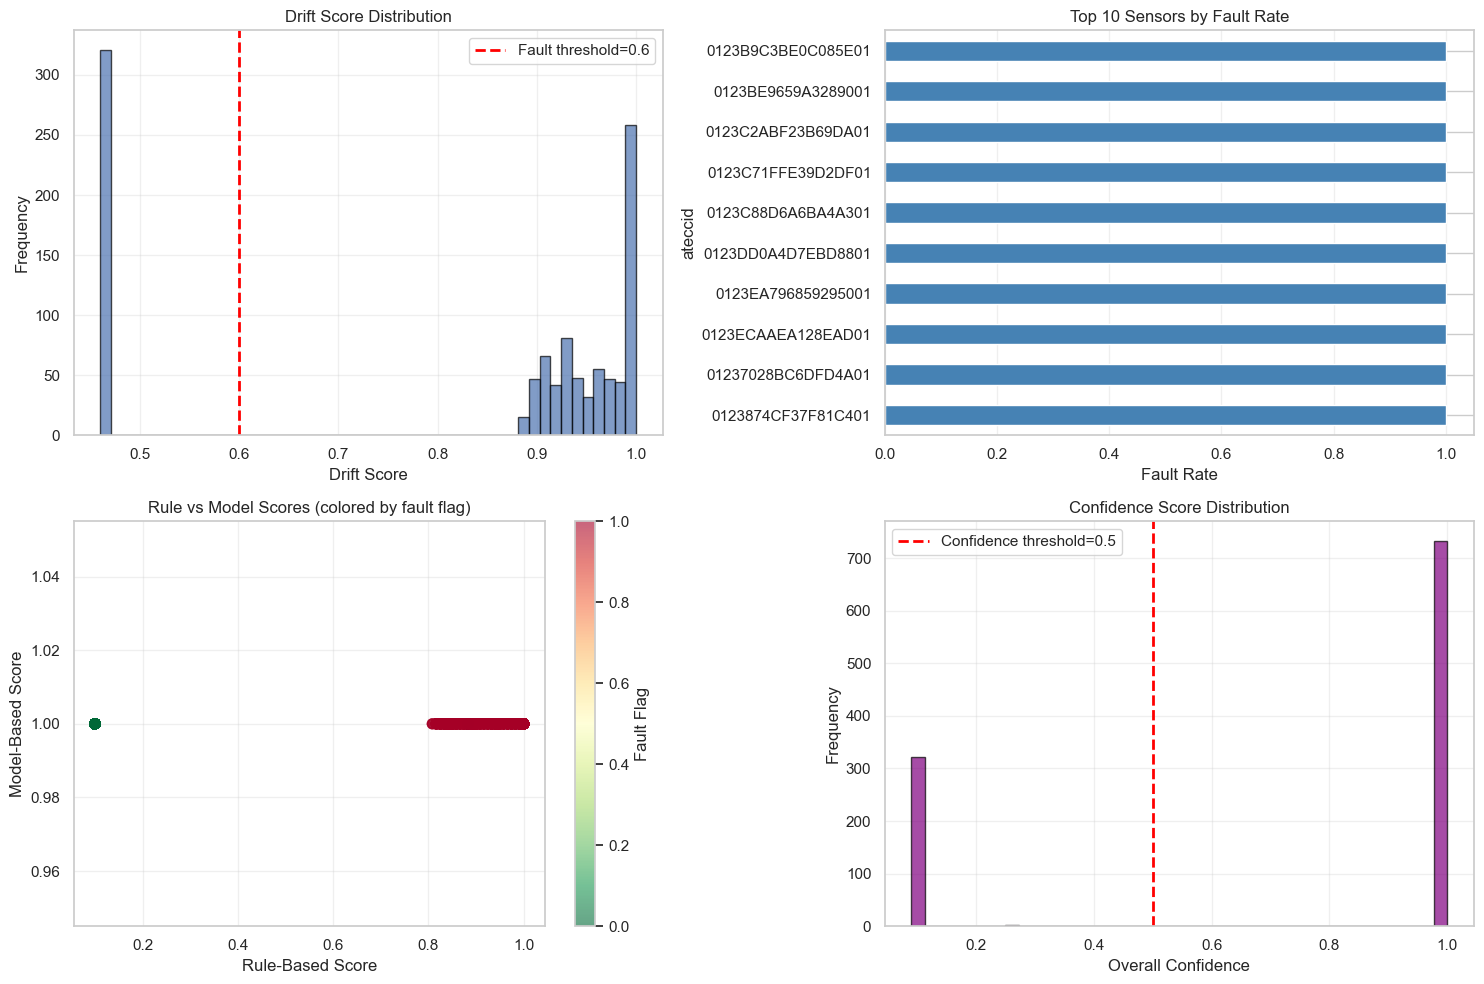

Diagnostics plots generated.


In [18]:
# Create comprehensive diagnostics plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Drift score distribution
axes[0, 0].hist(combined_scores['drift_score'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(FAULT_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Fault threshold={FAULT_THRESHOLD}')
axes[0, 0].set_xlabel('Drift Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Drift Score Distribution')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Fault rate by sensor (top 10)
fault_by_sensor = combined_scores.groupby(sensor_col)['binary_fault_flag'].agg(['sum', 'count'])
fault_by_sensor['fault_rate'] = fault_by_sensor['sum'] / fault_by_sensor['count']
fault_by_sensor_sorted = fault_by_sensor.sort_values('fault_rate', ascending=False).head(10)

fault_by_sensor_sorted['fault_rate'].plot(kind='barh', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_xlabel('Fault Rate')
axes[0, 1].set_title('Top 10 Sensors by Fault Rate')
axes[0, 1].grid(alpha=0.3, axis='x')

# 3. Rule score vs Model score scatter
scatter = axes[1, 0].scatter(
    combined_scores['final_rule_score'],
    combined_scores['model_residual_score'].fillna(0),
    c=combined_scores['binary_fault_flag'],
    cmap='RdYlGn_r',
    alpha=0.6,
    s=50
)
axes[1, 0].set_xlabel('Rule-Based Score')
axes[1, 0].set_ylabel('Model-Based Score')
axes[1, 0].set_title('Rule vs Model Scores (colored by fault flag)')
axes[1, 0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 0], label='Fault Flag')

# 4. Confidence distribution
axes[1, 1].hist(combined_scores['overall_confidence'], bins=40, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].axvline(CONFIDENCE_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Confidence threshold={CONFIDENCE_THRESHOLD}')
axes[1, 1].set_xlabel('Overall Confidence')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Confidence Score Distribution')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(data_dir / 'fault_score_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print('Diagnostics plots generated.')

In [19]:
# Top suspicious windows
top_fault_windows = combined_scores.nlargest(20, 'drift_score')[[
    sensor_col, 'window_start', 'drift_score', 'final_rule_score', 'model_residual_score',
    'binary_fault_flag', 'overall_confidence', 'raw_alert_hours', 'persistence_alert_hours'
]].copy()

top_fault_windows = top_fault_windows.rename(columns={
    sensor_col: 'sensor_id',
    'raw_alert_hours': 'hours_above_threshold',
    'persistence_alert_hours': 'persistence_alert_count'
})

print('Top 20 suspicious windows:')
print(top_fault_windows.to_string(index=False))

Top 20 suspicious windows:
         sensor_id              window_start  drift_score  final_rule_score  model_residual_score  binary_fault_flag  overall_confidence  hours_above_threshold  persistence_alert_count
01230B43B90B9BB401 2025-08-23 00:00:00+00:00          1.0               1.0                   1.0                  1                 1.0                     24                       24
01230B43B90B9BB401 2025-08-30 00:00:00+00:00          1.0               1.0                   1.0                  1                 1.0                     24                       24
01230B43B90B9BB401 2025-09-04 00:00:00+00:00          1.0               1.0                   1.0                  1                 1.0                     24                       24
01230B43B90B9BB401 2025-09-05 00:00:00+00:00          1.0               1.0                   1.0                  1                 1.0                     24                       24
01230B43B90B9BB401 2025-09-06 00:00:00+00:00    

In [20]:
# Examples: low, medium, high drift windows
low_drift = combined_scores[combined_scores['drift_score'] <= 0.20].sample(min(3, len(combined_scores[combined_scores['drift_score'] <= 0.20])))
med_drift = combined_scores[(combined_scores['drift_score'] > 0.35) & (combined_scores['drift_score'] < 0.65)].sample(min(3, len(combined_scores[(combined_scores['drift_score'] > 0.35) & (combined_scores['drift_score'] < 0.65)])))
high_drift = combined_scores[combined_scores['drift_score'] >= 0.75].sample(min(3, len(combined_scores[combined_scores['drift_score'] >= 0.75])))

examples = pd.concat([
    low_drift.assign(drift_category='Low'),
    med_drift.assign(drift_category='Medium'),
    high_drift.assign(drift_category='High')
], ignore_index=True)

print('\nExample windows by drift category:')
print(examples[[
    sensor_col, 'window_start', 'drift_category', 'drift_score', 'final_rule_score',
    'binary_fault_flag', 'overall_confidence'
]].to_string(index=False))


Example windows by drift category:
           ateccid              window_start drift_category  drift_score  final_rule_score  binary_fault_flag  overall_confidence
012335521BE30BEE01 2025-08-21 00:00:00+00:00         Medium        0.460          0.100000                  0                0.09
012334ADD304739201 2025-09-05 00:00:00+00:00         Medium        0.460          0.100000                  0                0.09
01231F0ED9653CF801 2025-08-27 00:00:00+00:00         Medium        0.460          0.100000                  0                0.09
0123A864F6CCC5FB01 2025-09-07 00:00:00+00:00           High        1.000          1.000000                  1                1.00
012330E186CB5BA801 2025-08-22 00:00:00+00:00           High        0.970          0.950000                  1                1.00
0123C71FFE39D2DF01 2025-09-05 00:00:00+00:00           High        0.945          0.908333                  1                1.00


In [21]:
# Diagnostic summary table
diagnostics = {
    'total_windows': len(combined_scores),
    'fault_windows': combined_scores['binary_fault_flag'].sum(),
    'fault_rate_pct': 100 * combined_scores['binary_fault_flag'].mean(),
    'mean_drift_score': combined_scores['drift_score'].mean(),
    'median_drift_score': combined_scores['drift_score'].median(),
    'std_drift_score': combined_scores['drift_score'].std(),
    'mean_rule_score': combined_scores['final_rule_score'].mean(),
    'mean_model_score': combined_scores['model_residual_score'].mean(),
    'mean_confidence': combined_scores['overall_confidence'].mean(),
    'unique_sensors': combined_scores[sensor_col].nunique(),
    'mean_windows_per_sensor': len(combined_scores) / combined_scores[sensor_col].nunique(),
    'fault_threshold': FAULT_THRESHOLD,
    'confidence_threshold': CONFIDENCE_THRESHOLD,
    'best_model': best_model_name,
    'model_val_r2': model_results[best_model_name]['r2_val']
}

diagnostics_df = pd.DataFrame([diagnostics]).T
diagnostics_df.columns = ['value']

print('\nDiagnostic Summary:')
print(diagnostics_df.to_string())


Diagnostic Summary:
                                    value
total_windows                        1056
fault_windows                         733
fault_rate_pct                  69.412879
mean_drift_score                 0.806979
median_drift_score                   0.93
std_drift_score                  0.231521
mean_rule_score                  0.678299
mean_model_score                      1.0
mean_confidence                   0.72196
unique_sensors                         33
mean_windows_per_sensor              32.0
fault_threshold                       0.6
confidence_threshold                  0.5
best_model               GradientBoosting
model_val_r2                     0.961239


## 8. Export Scored Outputs

In [22]:
# Prepare full scored sensor-window table
window_scores_export = combined_scores.copy()

# Merge with window-level feature data  
window_scores_export = window_scores_export.merge(
    window_features[[sensor_col, 'window_start', 'window_end', 'hours_with_data', 'mean_neighbour_coverage', 'min_neighbour_coverage', 'fallback_hours']],
    on=[sensor_col, 'window_start'],
    how='left'
)

# Select and order columns for export
export_columns = [
    sensor_col, 'window_start', 'window_end',
    'drift_score', 'binary_fault_flag',
    'neighbour_count', 'neighbour_mode_encoded', 'neighbour_count',
    'overall_confidence', 'scoring_confidence', 'neighbour_evidence_confidence', 'fallback_confidence',
    'final_rule_score', 'residual_magnitude_score', 'robust_z_score', 'persistence_score', 'instability_score',
    'model_residual_score',
    'raw_alert_hours', 'persistence_alert_hours', 'max_persistence_hours',
    'hours_in_window', 'hours_with_data', 'mean_neighbour_coverage', 'min_neighbour_coverage', 'fallback_hours'
]

# Filter to existing columns
export_columns = [col for col in export_columns if col in window_scores_export.columns]
window_scores_export = window_scores_export[export_columns]

# Rename columns for clarity
window_scores_export = window_scores_export.rename(columns={
    sensor_col: 'sensor_id',
    'neighbour_mode_encoded': 'has_neighbours',
    'hours_in_window': 'scored_hours',
    'mean_neighbour_coverage': 'mean_neigh_coverage',
    'min_neighbour_coverage': 'min_neigh_coverage'
})

print(f'Scored sensor-window table prepared: {window_scores_export.shape}')
print(f'\nColumns in export:')
for col in window_scores_export.columns:
    print(f'  - {col}')

Scored sensor-window table prepared: (1056, 23)

Columns in export:
  - sensor_id
  - window_start
  - window_end
  - drift_score
  - binary_fault_flag
  - overall_confidence
  - scoring_confidence
  - neighbour_evidence_confidence
  - fallback_confidence
  - final_rule_score
  - residual_magnitude_score
  - robust_z_score
  - persistence_score
  - instability_score
  - model_residual_score
  - raw_alert_hours
  - persistence_alert_hours
  - max_persistence_hours
  - scored_hours
  - hours_with_data
  - mean_neigh_coverage
  - min_neigh_coverage
  - fallback_hours


In [23]:
# Export 1: Full scored sensor-window table
sensor_window_scores_path = outputs / 'sensor_window_scores.csv'
window_scores_export.to_csv(sensor_window_scores_path, index=False)
print(f'✓ Exported: {sensor_window_scores_path}')

# Export 2: Top fault windows
top_fault_export = top_fault_windows.copy()
top_fault_windows_path = outputs / 'top_fault_windows.csv'
top_fault_export.to_csv(top_fault_windows_path, index=False)
print(f'✓ Exported: {top_fault_windows_path}')

# Export 3: Fault rule parameters
fault_params = {
    'rule_parameters': RULE_PARAMS,
    'scoring_thresholds': {
        'drift_score_fault_threshold': FAULT_THRESHOLD,
        'confidence_minimum_threshold': CONFIDENCE_THRESHOLD
    },
    'model_info': {
        'selected_model': best_model_name,
        'model_validation_r2': float(model_results[best_model_name]['r2_val']),
        'num_training_features': len(available_features)
    },
    'scoring_strategy': {
        'rule_based_weight': 0.6,
        'model_based_weight': 0.4,
        'components': {
            'residual_magnitude': 0.35,
            'robust_z_score': 0.35,
            'persistence': 0.20,
            'instability': 0.10
        }
    }
}
fault_params_path = outputs / 'fault_rule_parameters.json'
with open(fault_params_path, 'w') as f:
    json.dump(fault_params, f, indent=2)
print(f'✓ Exported: {fault_params_path}')

# Export 4: Score diagnostics
score_diagnostics_path = outputs / 'score_diagnostics.csv'
diagnostics_df.to_csv(score_diagnostics_path)
print(f'✓ Exported: {score_diagnostics_path}')

✓ Exported: ../data/sensor_window_scores.csv
✓ Exported: ../data/top_fault_windows.csv
✓ Exported: ../data/fault_rule_parameters.json
✓ Exported: ../data/score_diagnostics.csv


In [24]:
print('\n' + '='*60)
print('FAULT SCORING COMPLETE')
print('='*60)
print(f'\nGenerated outputs:')
print(f'  1. sensor_window_scores.csv - {window_scores_export.shape[0]} windows scored')
print(f'  2. top_fault_windows.csv - Top 20 suspicious windows')
print(f'  3. fault_rule_parameters.json - Documented rules and thresholds')
print(f'  4. score_diagnostics.csv - Diagnostic summary')
print(f'\nKey metrics:')
print(f'  - Total windows: {diagnostics["total_windows"]}')
print(f'  - Fault windows: {diagnostics["fault_windows"]} ({diagnostics["fault_rate_pct"]:.1f}%)')
print(f'  - Mean drift score: {diagnostics["mean_drift_score"]:.3f}')
print(f'  - Model: {diagnostics["best_model"]} (Val R²={diagnostics["model_val_r2"]:.3f})')
print('='*60)


FAULT SCORING COMPLETE

Generated outputs:
  1. sensor_window_scores.csv - 1056 windows scored
  2. top_fault_windows.csv - Top 20 suspicious windows
  3. fault_rule_parameters.json - Documented rules and thresholds
  4. score_diagnostics.csv - Diagnostic summary

Key metrics:
  - Total windows: 1056
  - Fault windows: 733 (69.4%)
  - Mean drift score: 0.807
  - Model: GradientBoosting (Val R²=0.961)
